<a href="https://colab.research.google.com/github/EmilioUcelayLojo/AA3/blob/laboratorios_practicas/lab9/lab9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eirasf/GCED-AA3/blob/main/lab9/lab9.ipynb)

# Práctica 9: One Class Network

## Pre-requisitos

### Instalar paquetes

Si la práctica requiere algún paquete de Python, habrá que incluir una celda en la que se instalen. Si usamos un paquete que se ha utilizado en prácticas anteriores, podríamos dar por supuesto que está instalado pero no cuesta nada satisfacer todas las dependencias en la propia práctica para reducir las dependencias entre ellas.

### NOTA: En <font color='red'>Google Colab</font> hay que instalar los paquetes EN CADA EJECUCIÓN

In [60]:
# Ejemplo de instalación de tensorflow 2.0
%tensorflow_version 2.x
# !pip3 install tensorflow  # NECESARIO SOLO SI SE EJECUTA EN LOCAL
import tensorflow as tf

# Hacemos los imports que sean necesarios
import numpy as np

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


# One Class sobre datos artificiales

Lo primero que tenemos que hacer es definir los datos a utilizar.

In [61]:
random_state = 42
rng = np.random.RandomState(random_state)
#  datos de entrenamiento
X = 0.3 * rng.randn(5000, 2)
x_train = np.r_[X + 2, X - 2]
#  datos de test en la misma distribución que los datos de entrenamiento
X = 0.3 * rng.randn(200, 2)
x_test = np.r_[X + 2, X - 2]
#  outliers
x_outliers = rng.uniform(low=-4, high=4, size=(200, 2))

## Crea tu propia red para la detección de anomalías

Vamos a crear nuestra propia red para la detección de anomalías. Para ello, utilizaremos una red que transforme cada elemento de entrada en un valor numérico. Optimizaremos sus pesos para que:
* Sean pequeños (regularización L2)
* La salida sea menor que un un valor `r` que iremos modificando en cada epoch.
En cada epoch, calcularemos `r` de manera que solo una pequeña fracción de los datos $\nu$ obtenga una salida $\tilde{y}$ mayor que `r`. De esta manera, tras varias epoch, las entradas anómalas serán las que excedan dicho valor ($\tilde{y} > r$).

Definiremos una red cualquiera, que nos **transforme los datos de entrada en una salida de un único elemento**. Esta red va a cumplir una serie de características:

* La capa anterior a la salida serán las llamadas **deep features**.
* Todas las capas (incluyendo la última) deben incluir regularización.
* La función de coste es $$L(y, \tilde{y}) = \dfrac{1}{2} \| w^2 \| + \dfrac{1}{\nu} \dfrac{1}{N} \sum_{i=1}^N \max(0, r - \tilde{y}) $$ donde $\tilde{y}$ es la salida de la red, $\nu$ es un hiperparámetro entre 0 y 1, y $r$ es un parámetro no entrenable, pero que va a ser modificado en cada epoch.
* Al final del cada epoch, r va a ser modificado al valor del $\nu$-cuantil de los datos de entrada (este valor será modificado gracias al Callback proporcionado a continuación).
* Para la predicción, se considerará un dato típico si $\tilde{y} > r$. En caso contrario, será un dato atípico.

In [62]:
class ChangeRCallback(tf.keras.callbacks.Callback):
   def __init__(self, train_data, delta=.025, steps=3):
       super().__init__()
       self.train_data = train_data
       self.delta = delta
       self.steps = steps
       self.cont = 0

   def on_epoch_end(self, epoch, logs=None):
       sorted_values = np.sort(self.model.predict(self.train_data).flatten())
       new_value = sorted_values[int(len(sorted_values) * (1. - self.model.nu))]
       old_value = self.model.r.numpy()
       print('Cambiando r a', new_value, ', max:', sorted_values.max(), ', min:', sorted_values.min())
       self.model.r.assign(new_value)
       if np.abs(old_value - new_value) < self.delta:
            self.cont += 1
            if self.cont >= self.steps:
                print('Convergencia obtenida. Finalizando el entrenamiento.')
                self.model.stop_training = True
       else:
            self.cont = 0

Tu trabajo es crear el modelo y entrenarlo.

In [63]:
# TODO: implementa la red de detección de anomalías

class DetectorAnomalias:

    def __init__(self, input_shape, nu=0.5):
        # TODO: define el modelo
        # Creamos un modelo secuencial en TensorFlow Keras
        self.model = tf.keras.models.Sequential([
                      tf.keras.layers.InputLayer(input_shape=input_shape),
                      tf.keras.layers.Dense(
                          1,
                          activation='linear',
                          kernel_regularizer=tf.keras.regularizers.l2(0.01)  # Regularización en la única capa
                      )
                  ])

        # Inicializamos r y nu como variables de TensorFlow no entrenables
        self.model.r = tf.Variable(1.0, trainable=False, name='r', dtype=tf.float32)
        self.model.nu = tf.Variable(nu, trainable=False, name='nu', dtype=tf.float32)

        # TODO: crea el optimizador
        # Usamos Adam como optimizador con tasa de aprendizaje 0.001
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

        # TODO: compila el modelo
        # Compilamos con la función de pérdida personalizada definida más abajo
        self.model.compile(loss=self.loss_function, optimizer=self.optimizer)

    def loss_function(self, y_true, y_pred):
        # TODO: crea la función de pérdida personalizada
        # ReLU aplicado a (r - salida)
        relu_loss = tf.nn.relu(self.model.r - y_pred)
        # Pérdida total, escalada por nu
        total_loss = (1.0 / self.model.nu) * tf.reduce_mean(relu_loss)
        return total_loss

    def fit(self, X, y=None, sample_weight=None):
        # TODO: entrena el modelo
        # Creamos una "dummy" salida (no se usa) porque Keras lo exige
        dummy_y = np.zeros((len(X), 1))

        # Entrenamos el modelo con un batch_size de 32, 100 epochs y usando el callback para actualizar r
        self.model.fit(
            X, dummy_y,
            batch_size=128,
            epochs=100,
            callbacks=[ChangeRCallback(X, delta=0.01)] # Callback personalizado para ajustar r en cada epoch
        )

    def predict(self, X):
        # TODO: devuelve la predicción del modelo
        # Obtenemos la predicción de la red para los datos de entrada
        y_pred = self.model.predict(X)
        return y_pred

    # def __del__(self):
    #     # TODO: borra el modelo
    #     # Liberamos la memoria de TensorFlow en GPU/CPU
    #     tf.keras.backend.clear_session()


### Entrena el modelo.

Usa lo hecho anteriormente para entrenar tu modelo.

In [64]:
# TODO: Define el modelo
# Creamos una instancia del DetectorAnomalias con la forma de entrada (2,) y varios nu
detector = DetectorAnomalias(input_shape=(2,), nu=0.9)

In [65]:
# TODO: Entrena tu modelo
# Entrenamos el modelo con los datos de entrenamiento x_train
detector.fit(x_train)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Cambiando r a -4.175666 , max: 5.376654 , min: -5.465176
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.7650
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Cambiando r a -4.101738 , max: 5.3123527 , min: -5.3772383
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0464
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Cambiando r a -4.0323014 , max: 5.2504845 , min: -5.294128
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0454
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Cambiando r a -3.9521227 , max: 5.178869 , min: -5.1978016
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0471
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Cambiando r a -3.8619163 , max: 5.0997357 , min: -5.0894537
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0432
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Cambiando r a -3.7668986 , max: 5.0197263 , min: -4.9747286
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.042

## Evaluando el modelo

Una vez entrenado, para evaluar el modelo sólo hay que tener en cuenta lo siguiente:

  1. Si la salida es mayor que r, es un dato típico.
  1. Si la salida es menor que r, es un dato atípico.

### TRABAJO: Evalúa el modelo con los datos del conjunto de test, y con los outliers. Visualiza los datos típicos y atípicos con una gráfica.

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Porcentaje de datos típicos en el conjunto de test: 93.25%


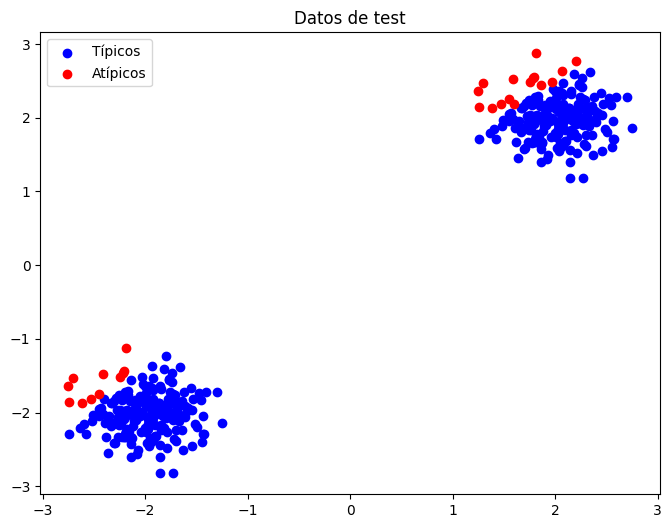

In [66]:
# TODO: Evalúa el modelo con los datos del conjunto de test. Indica el porcentaje de datos etiquetados como típicos, y visualiza los datos
import matplotlib.pyplot as plt

# Obtenemos las predicciones del modelo para los datos de test
y_pred_test = detector.predict(x_test)

# Obtenemos el valor de r del modelo
r = detector.model.r.numpy()

# Etiquetamos los datos como típicos o atípicos según si la predicción es mayor o menor que r
y_pred_labels_test = (y_pred_test.flatten() > r).astype(int)

# Calculamos el porcentaje de datos etiquetados como típicos
porcentaje_tipicos_test = np.sum(y_pred_labels_test) / len(y_pred_labels_test) * 100

# Imprimimos el porcentaje de datos etiquetados como típicos
print(f"Porcentaje de datos típicos en el conjunto de test: {porcentaje_tipicos_test:.2f}%")

# Visualizamos los datos
plt.figure(figsize=(8, 6))
plt.scatter(x_test[y_pred_labels_test == 1, 0], x_test[y_pred_labels_test == 1, 1], color='blue', label='Típicos')
plt.scatter(x_test[y_pred_labels_test == 0, 0], x_test[y_pred_labels_test == 0, 1], color='red', label='Atípicos')
plt.title('Datos de test')
plt.legend()
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Porcentaje de datos atípicos en el conjunto de outliers: 50.50%


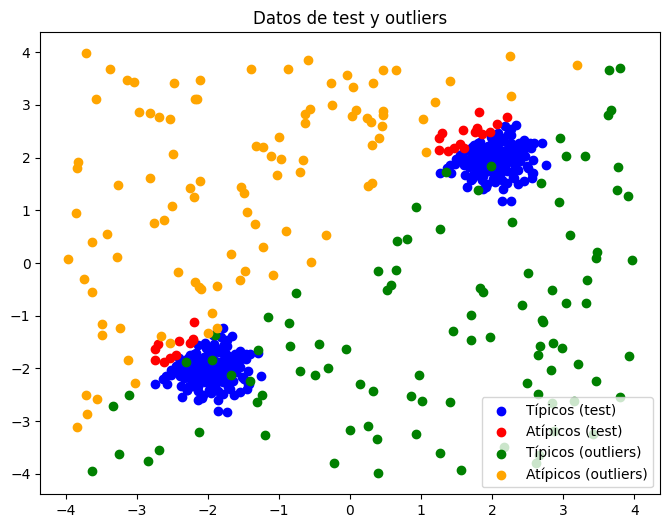

In [67]:
# TODO: Evalúa el modelo con los datos del conjunto de outliers. Indica el porcentaje de datos etiquetados como atípicos, y visualiza los datos en conjunto con los de test

# Obtenemos las predicciones del modelo para los outliers
y_pred_outliers = detector.predict(x_outliers)

# Etiquetamos los datos como típicos o atípicos según si la predicción es mayor o menor que r
y_pred_labels_outliers = (y_pred_outliers.flatten() > r).astype(int)

# Calculamos el porcentaje de datos etiquetados como atípicos
porcentaje_atipicos_outliers = np.sum(y_pred_labels_outliers == 0) / len(y_pred_labels_outliers) * 100

# Imprimimos el porcentaje de datos etiquetados como atípicos
print(f"Porcentaje de datos atípicos en el conjunto de outliers: {porcentaje_atipicos_outliers:.2f}%")

# Visualizamos los datos
plt.figure(figsize=(8, 6))
plt.scatter(x_test[y_pred_labels_test == 1, 0], x_test[y_pred_labels_test == 1, 1], color='blue', label='Típicos (test)')
plt.scatter(x_test[y_pred_labels_test == 0, 0], x_test[y_pred_labels_test == 0, 1], color='red', label='Atípicos (test)')
plt.scatter(x_outliers[y_pred_labels_outliers == 1, 0], x_outliers[y_pred_labels_outliers == 1, 1], color='green', label='Típicos (outliers)')
plt.scatter(x_outliers[y_pred_labels_outliers == 0, 0], x_outliers[y_pred_labels_outliers == 0, 1], color='orange', label='Atípicos (outliers)')
plt.title('Datos de test y outliers')
plt.legend()
plt.show()

¿Qué resultados has obtenido? Si el número de outliers detectado es bajo (inferior al 30%), puedes estar cometiendo algún error, entre ellos:

* Sobreentrenar el modelo. Prueba a usar un delta distinto en el callback.
* Usar un valor de $\nu$ demasiado alto.

Prueba distintas configuraciones para ver su efecto.

# ¡ENHORABUENA! Has completado la práctica de oneclass.
